In [30]:
#Names: Valerie Jimenez, Trevor Henderson (Monday and Wednesday)
#dataset: https://www.kaggle.com/datasets/dnkumars/cybersecurity-intrusion-detection-dataset


# Problem 2: Binary Classification - Detecting Cybersecurity Intrusions
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA

In [31]:
# Load the cybersecurity intrusion dataset from a CSV file
df = pd.read_csv('cybersecurity_intrusion_data.csv')

# Preview the first few rows
print("Dataset Preview:")
print(df.head())
print(f"\nDataset Shape: {df.shape}")
print(f"\nColumn Types:\n{df.dtypes}")

Dataset Preview:
  session_id  network_packet_size protocol_type  login_attempts  \
0  SID_00001                  599           TCP               4   
1  SID_00002                  472           TCP               3   
2  SID_00003                  629           TCP               3   
3  SID_00004                  804           UDP               4   
4  SID_00005                  453           TCP               5   

   session_duration encryption_used  ip_reputation_score  failed_logins  \
0        492.983263             DES             0.606818              1   
1       1557.996461             DES             0.301569              0   
2         75.044262             DES             0.739164              2   
3        601.248835             DES             0.123267              0   
4        532.540888             AES             0.054874              1   

  browser_type  unusual_time_access  attack_detected  
0         Edge                    0                1  
1      Firefox     

In [32]:
# Drop session_id — it is just an identifier, not a meaningful feature
df = df.drop(columns=['session_id'])

# Fill missing values in encryption_used with 'None' before encoding
df['encryption_used'] = df['encryption_used'].fillna('None')

# Encode categorical columns using LabelEncoder
# LabelEncoder converts string labels into numeric values
le = LabelEncoder()
categorical_cols = ['protocol_type', 'encryption_used', 'browser_type']
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

class_names = ['No Attack', 'Attack Detected']

print("Data after encoding:")
print(df.head())

Data after encoding:
   network_packet_size  protocol_type  login_attempts  session_duration  \
0                  599              1               4        492.983263   
1                  472              1               3       1557.996461   
2                  629              1               3         75.044262   
3                  804              2               4        601.248835   
4                  453              1               5        532.540888   

   encryption_used  ip_reputation_score  failed_logins  browser_type  \
0                1             0.606818              1             1   
1                1             0.301569              0             2   
2                1             0.739164              2             0   
3                1             0.123267              0             4   
4                0             0.054874              1             2   

   unusual_time_access  attack_detected  
0                    0                1  
1          

In [33]:
# Separate features (X) and target label (y)
# X contains all columns except the target
# y is what we are trying to predict: 0 = No Attack, 1 = Attack Detected
X = df.drop(columns=['attack_detected'])
y = df['attack_detected']

print(f"Features shape: {X.shape}")
print(f"\nTarget distribution:")
print(y.value_counts())

Features shape: (9537, 9)

Target distribution:
attack_detected
0    5273
1    4264
Name: count, dtype: int64


In [34]:
# Scale the features using StandardScaler
# This is critical for SVM — it is distance-based, so features on different
# scales (e.g., session_duration in seconds vs. ip_reputation_score 0-1)
# would unfairly dominate the decision boundary without scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Features after scaling (first 3 rows):")
print(X_scaled[:3])

Features after scaling (first 3 rows):
[[ 0.49689911 -0.38622555 -0.01634592 -0.38112504  0.36574559  1.55493002
  -0.50077948  0.06322462 -0.41998902]
 [-0.14332201 -0.38622555 -0.52579383  0.97295964  0.36574559 -0.16802943
  -1.46795928  0.90419148 -0.41998902]
 [ 0.64813245 -0.38622555 -0.52579383 -0.91250324  0.36574559  2.3019501
   0.46640033 -0.77774223 -0.41998902]]


In [35]:
# Split the data into training set (80%) and testing set (20%)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples:  {X_test.shape[0]}")

Training samples: 7629
Testing samples:  1908


In [36]:
# Create an SVM classifier with a linear kernel
# kernel='linear' means we are drawing a straight hyperplane to separate the classes
# C=1.0 controls the trade-off between smooth decision boundary and classifying training points correctly
svm_classifier = SVC(kernel='linear', C=1.0)

# Train the SVM model using the training data
svm_classifier.fit(X_train, y_train)

print("Model training complete.")

Model training complete.


In [37]:
# Make predictions on the test data
y_pred = svm_classifier.predict(X_test)

# Calculate the accuracy of our model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['No Attack', 'Attack Detected']))

Accuracy: 74.00%

Classification Report:
                 precision    recall  f1-score   support

      No Attack       0.73      0.83      0.78      1042
Attack Detected       0.75      0.63      0.69       866

       accuracy                           0.74      1908
      macro avg       0.74      0.73      0.73      1908
   weighted avg       0.74      0.74      0.74      1908



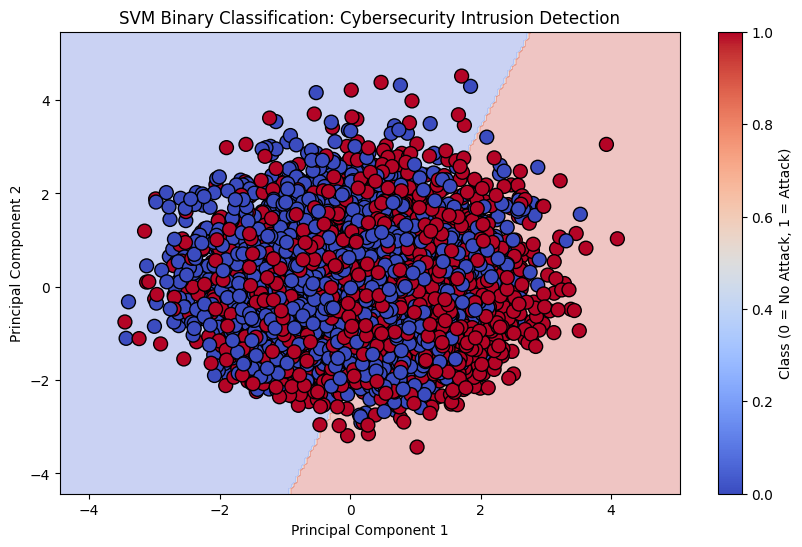


Number of support vectors: 4708


In [38]:
# Visualize the decision boundary
# Because we have 9 features, we cannot plot directly like the iris example (which used 2 features).
# Instead, we use PCA (Principal Component Analysis) to reduce the data to 2 dimensions
# so we can visualize it. We then retrain SVM on these 2 components for the plot only.
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Retrain SVM on the 2 PCA components (for visualization purposes only)
svm_viz = SVC(kernel='linear', C=1.0)
svm_viz.fit(X_pca, y)

# Create a mesh grid to plot decision regions
x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05),
                     np.arange(y_min, y_max, 0.05))

# Predict class for each point in the mesh
Z = svm_viz.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot the decision boundary and the data points
plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, edgecolors='k', cmap='coolwarm', s=100)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('SVM Binary Classification: Cybersecurity Intrusion Detection')
plt.colorbar(label='Class (0 = No Attack, 1 = Attack)')
plt.show()

# Print support vectors (the critical points that define the decision boundary)
print(f"\nNumber of support vectors: {len(svm_classifier.support_vectors_)}")

In [39]:
# Show predictions for 10 samples from the test set
print(f"{'Actual':<20} {'Predicted':<20} {'Correct?'}")
print("-" * 55)
for i in range(min(10, len(y_test))):
    actual = str(class_names[y_test.iloc[i]])
    predicted = str(class_names[y_pred[i]])
    correct = "✓" if y_test.iloc[i] == y_pred[i] else "✗ (Error)"
    print(f"{actual:<20} {predicted:<20} {correct}")

Actual               Predicted            Correct?
-------------------------------------------------------
No Attack            No Attack            ✓
No Attack            No Attack            ✓
Attack Detected      Attack Detected      ✓
Attack Detected      No Attack            ✗ (Error)
No Attack            Attack Detected      ✗ (Error)
No Attack            No Attack            ✓
No Attack            No Attack            ✓
Attack Detected      Attack Detected      ✓
No Attack            No Attack            ✓
No Attack            Attack Detected      ✗ (Error)


This program looks at network activity data and learns to spot potential cyberattacks. It uses a method called Support Vector Machine (SVM), which works by drawing an invisible boundary line that separates normal traffic from suspicious behavior. The benefit of SVM is that it focuses on the hardest cases near that boundary, making it good at handling situations where the difference between normal and malicious activity is not obvious. It studies patterns like login attempts, packet size, and IP reputation to make its decisions. When tested on new data, the model correctly identified attacks about 74% of the time.